In [7]:
import pandas as pd
import os
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.image as img

In [20]:
records = []

# training
for root, d, files in os.walk("./data_upload_v3/train"):
    # non-covid
    if "non" in root:
        for file in files:
            with open(os.path.join(root, file), 'rb') as f:
                img_bytes = f.read()
                records.append({
                    "filename": file,
                    "image": img_bytes,
                    "label": 0
                })
    # covid
    elif "covid" in root:
        for file in files:
            with open(os.path.join(root, file), 'rb') as f:
                img_bytes = f.read()
                records.append({
                    "filename": file,
                    "image": img_bytes,
                    "label": 1
                })
                
for root, d, files in os.walk("./data_upload_v3/test"):
    # non-covid
    if "non/" in root:
        for file in files:
            with open(os.path.join(root, file), 'rb') as f:
                img_bytes = f.read()
                records.append({
                    "filename": file,
                    "image": img_bytes,
                    "label": 0
                })
    # covid
    elif "covid" in root:
        for file in files:
            with open(os.path.join(root, file), 'rb') as f:
                img_bytes = f.read()
                records.append({
                    "filename": file,
                    "image": img_bytes,
                    "label": 1
                })
    
table = pa.Table.from_pylist(records)
pq.write_table(table, "data.parquet")

In [21]:
df = pd.read_parquet("data.parquet")
df

,filename,image,label
0,Lung Opacity-patient25024-study1-view1_frontal...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
1,No Finding-patient33253-study1-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
2,Pleural Effusion-patient36661-study2-view1_fro...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
3,Fracture-patient02805-study1-view2_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
4,No Finding-patient23220-study2-view1_frontal.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,0
...,...,...,...
5179,1-s2.0-S1684118220300682-main.pdf-003-b1.png,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,1
5180,fff49165-b22d-4bb4-b9d1-d5d62c52436c.annot.ori...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,1
5181,yxppt-2020-02-19_00-51-27_287214-day10.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1
5182,covid-19-pneumonia-24-day12.jpg,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...,1


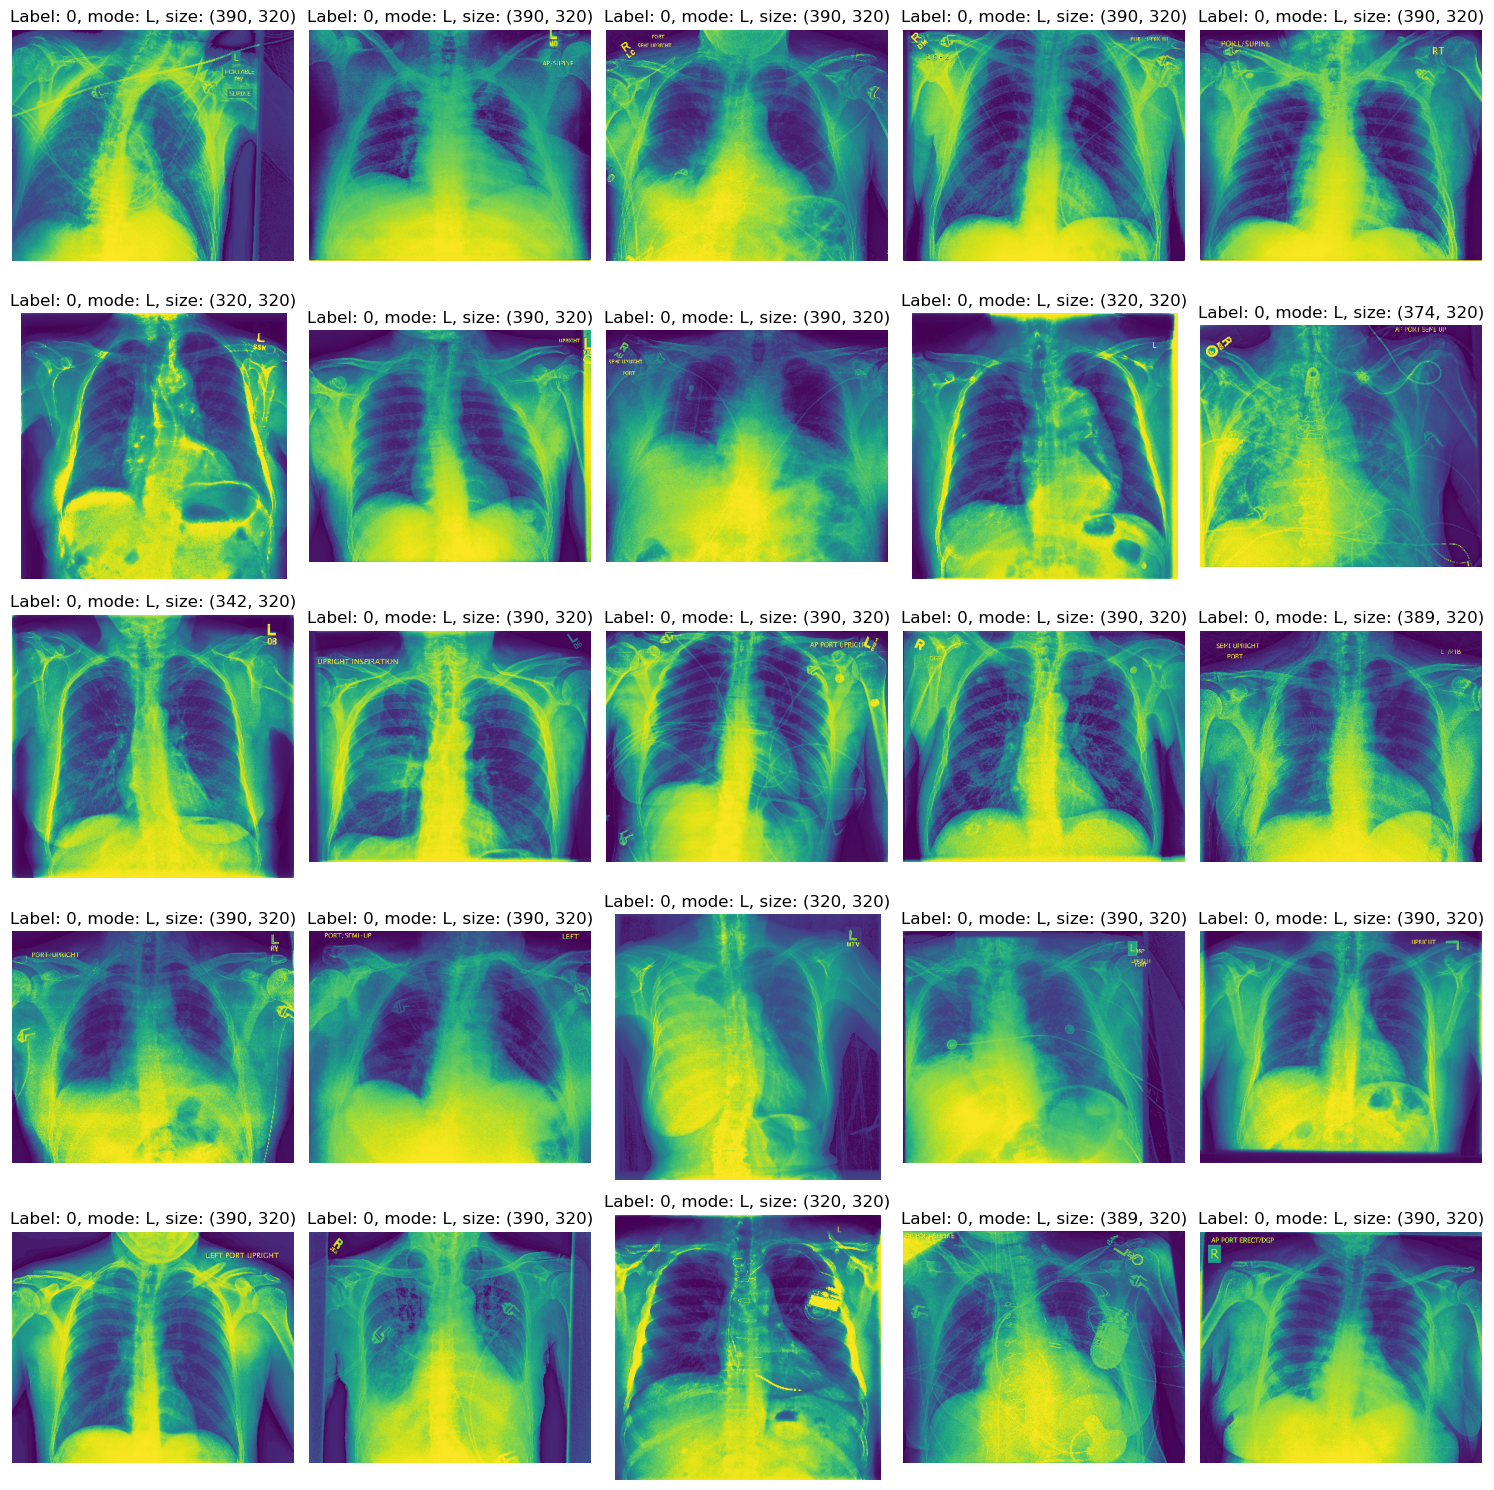

In [22]:
import io
from PIL import Image

# preview 25 images from dataframe and plot them in a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, ax in enumerate(axes.flatten()):
    if i >= len(df):
        break
    image_bytes = df.iloc[i]['image']
    image = Image.open(io.BytesIO(image_bytes))
    ax.imshow(image)
    ax.set_title(f"Label: {df.iloc[i]['label']}, mode: {image.mode}, size: {image.size}")
    ax.axis('off')
plt.tight_layout()
plt.show()